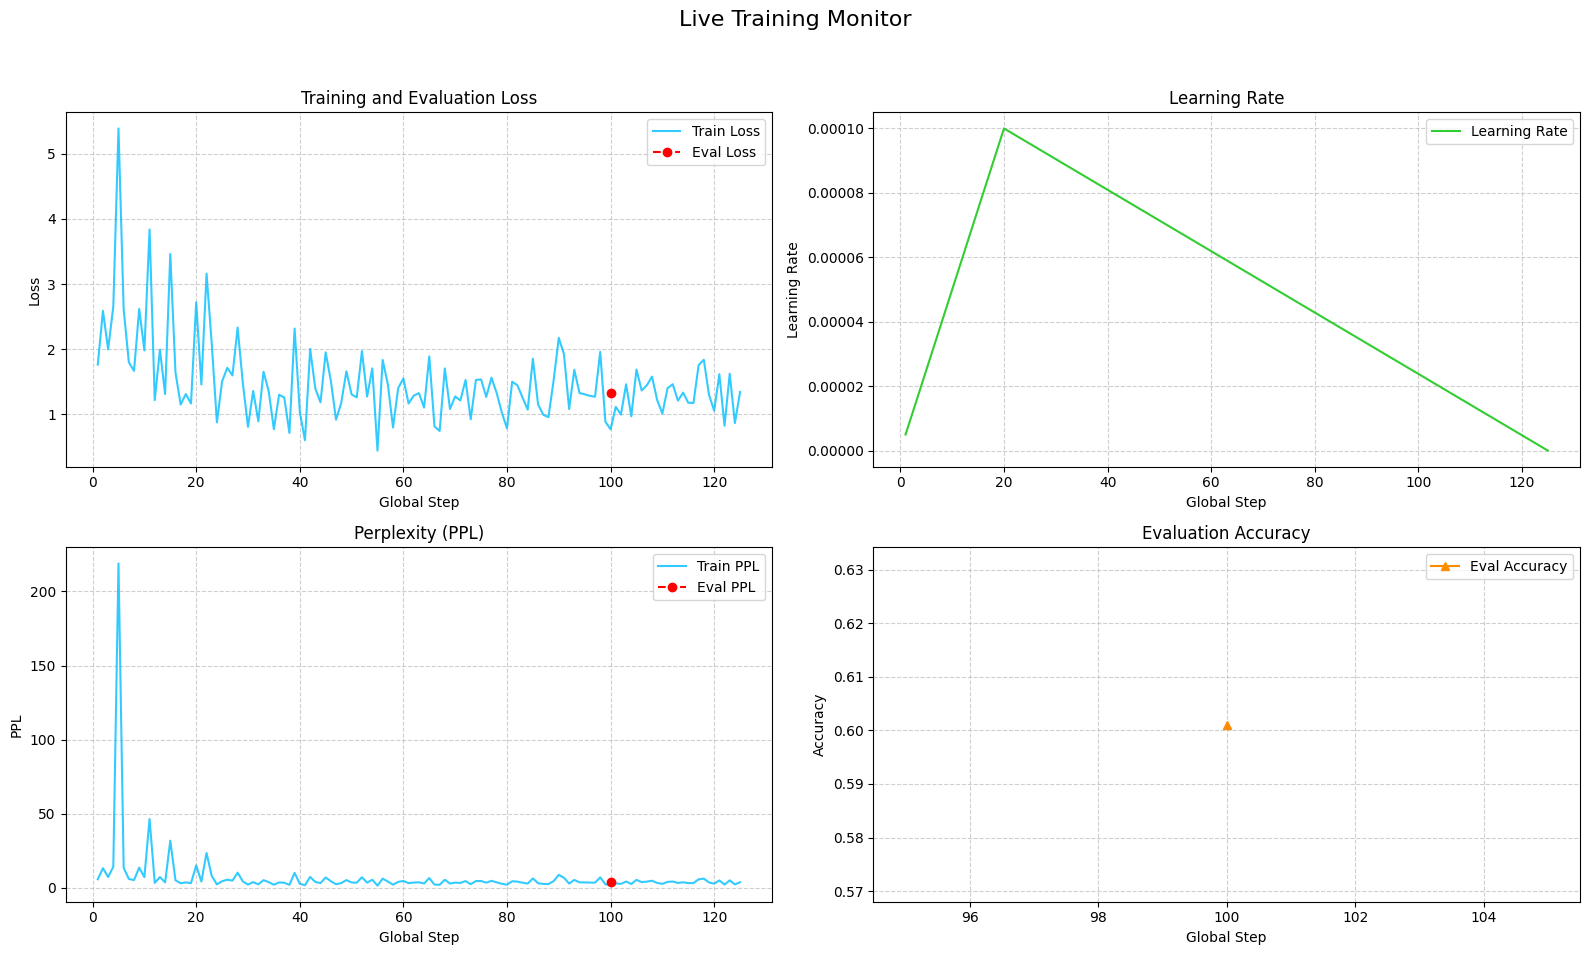

In [2]:
# 魔法命令，让 Matplotlib 的图表直接在 Notebook 的输出区域显示
%matplotlib inline

import re
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output # 导入关键的 clear_output 函数
from datetime import datetime

# ===============================================================
# 1. 配置你的日志文件路径和刷新间隔
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
log_file_path = 'training.log' # <--- 修改这里！
update_interval_seconds = 10   # 图表每 10 秒刷新一次
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# ===============================================================


def parse_log_line(line):
    """解析单行日志，提取训练和评估指标。 (此函数与之前相同)"""
    train_pattern = re.compile(
        r"loss: (?P<loss>[\d\.]+), "
        r"learning_rate: (?P<lr>[\d.e-]+), "
        r"global_step: (?P<step>\d+),.*?"
        r"ppl: (?P<ppl>[\d\.]+)"
    )
    eval_pattern = re.compile(
        r"eval_loss: (?P<eval_loss>[\d\.]+), "
        r"eval_accuracy: (?P<eval_acc>[\d\.]+),.*?"
        r"eval_ppl: (?P<eval_ppl>[\d\.]+)"
    )
    train_match = train_pattern.search(line)
    if train_match: return {k: float(v) for k, v in train_match.groupdict().items()}
    eval_match = eval_pattern.search(line)
    if eval_match: return {k: float(v) for k, v in eval_match.groupdict().items()}
    return None

def plot_metrics(data):
    """根据解析的数据进行绘图。"""
    if not data or not data['step']:
        print("텅텅 未从日志中解析出任何有效数据，等待日志更新...")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Live Training Monitor', fontsize=16)

    # ... (这部分绘图逻辑和之前完全一样) ...
    # 子图 1: Loss
    ax1 = axes[0, 0]
    ax1.plot(data['step'], data['loss'], label='Train Loss', color='deepskyblue', alpha=0.8)
    if data['eval_step']: ax1.plot(data['eval_step'], data['eval_loss'], label='Eval Loss', color='red', marker='o', linestyle='--')
    ax1.set_title('Training and Evaluation Loss'); ax1.set_xlabel('Global Step'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    # 子图 2: Learning Rate
    ax2 = axes[0, 1]
    ax2.plot(data['step'], data['lr'], label='Learning Rate', color='limegreen')
    ax2.set_title('Learning Rate'); ax2.set_xlabel('Global Step'); ax2.set_ylabel('Learning Rate')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)
    
    # 子图 3: PPL
    ax3 = axes[1, 0]
    ax3.plot(data['step'], data['ppl'], label='Train PPL', color='deepskyblue', alpha=0.8)
    if data['eval_step']: ax3.plot(data['eval_step'], data['eval_ppl'], label='Eval PPL', color='red', marker='o', linestyle='--')
    ax3.set_title('Perplexity (PPL)'); ax3.set_xlabel('Global Step'); ax3.set_ylabel('PPL')
    ax3.legend(); ax3.grid(True, linestyle='--', alpha=0.6)
    
    # 子图 4: Accuracy
    ax4 = axes[1, 1]
    if data['eval_step']: ax4.plot(data['eval_step'], data['eval_acc'], label='Eval Accuracy', color='darkorange', marker='^')
    ax4.set_title('Evaluation Accuracy'); ax4.set_xlabel('Global Step'); ax4.set_ylabel('Accuracy')
    ax4.legend(); ax4.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 调整布局为 suptitle 留出空间
    plt.show()

# --- 主循环：实时监控 ---
try:
    print("🚀 开始实时监控日志文件... (点击下方的停止按钮来中断)")
    while True:
        # 清空上一次的输出
        # wait=True 参数可以防止屏幕闪烁，它会等到有新内容输出时才清空旧内容
        clear_output(wait=True)
        
        data = defaultdict(list)
        try:
            with open(log_file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parsed_data = parse_log_line(line)
                    if parsed_data:
                        if 'step' in parsed_data:
                            data['step'].append(int(parsed_data['step']))
                            data['loss'].append(parsed_data['loss'])
                            data['lr'].append(parsed_data['lr'])
                            data['ppl'].append(parsed_data['ppl'])
                        elif 'eval_loss' in parsed_data:
                            if data['step']:
                                last_step = data['step'][-1]
                                if not data['eval_step'] or data['eval_step'][-1] != last_step:
                                    data['eval_step'].append(last_step)
                                    data['eval_loss'].append(parsed_data['eval_loss'])
                                    data['eval_acc'].append(parsed_data['eval_acc'])
                                    data['eval_ppl'].append(parsed_data['eval_ppl'])
        except FileNotFoundError:
            print(f"❌ 错误: 找不到日志文件 {log_file_path}，请检查路径。")
            break # 如果文件不存在，则停止循环

        # 打印当前时间和状态
        print(f"✅ 最后更新于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # 绘制图表
        plot_metrics(data)
        
        # 等待指定的间隔时间
        time.sleep(update_interval_seconds)

except KeyboardInterrupt:
    print("\n🛑 监控已由用户手动停止。")
    # (可选) 在停止后，再绘制一次最终的图表
    print("正在生成最终图表...")
    clear_output(wait=True)
    plot_metrics(data)

In [ ]:
# 魔法命令，让 Matplotlib 的图表直接在 Notebook 的输出区域显示
%matplotlib inline

import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interactive

# ===============================================================
# 1. 配置你的日志文件根目录
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
base_dir = 'pics' # <--- 修改这里！指向包含所有实验文件夹的根目录
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# ===============================================================


def parse_log_line(line):
    """
    解析单行日志，提取训练指标。
    (此函数直接复用您提供的代码)
    """
    train_pattern = re.compile(
        r"loss: (?P<loss>[\d\.]+), "
        r"learning_rate: (?P<lr>[\d.e-]+), "
        r"global_step: (?P<step>\d+),.*?"
        r"ppl: (?P<ppl>[\d\.]+)"
    )
    # 为了对比Loss，我们主要关注训练日志
    train_match = train_pattern.search(line)
    if train_match:
        return {k: float(v) for k, v in train_match.groupdict().items()}
    return None

def load_all_logs(base_path):
    """
    遍历指定路径下的所有子文件夹，加载并解析每个文件夹中的 training.log 文件。
    """
    all_data = {}
    # 确保基础路径存在
    if not os.path.isdir(base_path):
        print(f"❌ 错误: 找不到根目录 '{base_path}'")
        return None
        
    # 获取所有子文件夹作为实验名称
    experiment_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    if not experiment_names:
        print(f"❌ 错误: 在 '{base_path}' 下没有找到任何实验文件夹。")
        return None

    print(f"🔍 在 '{base_path}' 中找到 {len(experiment_names)} 个实验: {', '.join(experiment_names)}")

    for exp_name in experiment_names:
        log_file_path = os.path.join(base_path, exp_name, 'training.log')
        
        # defaultdict(list) 让我们能方便地 .append 数据
        data = defaultdict(list)
        
        try:
            with open(log_file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parsed = parse_log_line(line)
                    if parsed and 'step' in parsed:
                        data['step'].append(int(parsed['step']))
                        data['loss'].append(parsed['loss'])
            
            # 只有当成功解析出数据时才添加到总数据集中
            if data['step']:
                all_data[exp_name] = data
                print(f"  ✅ 成功加载实验 '{exp_name}' ({len(data['step'])} 个数据点)")
            else:
                print(f"  ⚠️ 警告: 实验 '{exp_name}' 的日志文件为空或不包含有效数据。")

        except FileNotFoundError:
            print(f"  ❌ 错误: 在 '{exp_name}' 文件夹中找不到 'training.log' 文件。")
            
    return all_data

# --- 主绘图函数 ---
def plot_comparison(**kwargs):
    """
    根据传入的布尔值参数（来自复选框）绘制对比图。
    """
    plt.style.use('seaborn-v0_8-whitegrid') # 使用更美观的样式
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 检查是否有任何实验被选中用于绘图
    has_plotted = False
    for exp_name, should_plot in kwargs.items():
        if should_plot and exp_name in all_log_data:
            data = all_log_data[exp_name]
            # 绘制 Loss 曲线
            ax.plot(data['step'], data['loss'], label=exp_name, alpha=0.8, lw=2)
            has_plotted = True
            
    # 设置图表属性
    ax.set_title('Training Loss Comparison', fontsize=16)
    ax.set_xlabel('Global Step', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    
    # 只有当有曲线被绘制时才显示图例
    if has_plotted:
        ax.legend(title='Experiments', fontsize=10)
    else:
        # 如果没有选择任何实验，显示提示信息
        ax.text(0.5, 0.5, '请通过勾选上方的复选框来选择要显示的实验', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14, color='gray')

    # ax.set_yscale('log') # Loss 变化范围可能很大，使用对数坐标轴效果更好
    plt.tight_layout()
    plt.show()


# --- 主程序入口 ---
# 1. 加载所有数据
all_log_data = load_all_logs(base_dir)

if all_log_data:
    # 2. 为每个加载的实验创建一个复选框控件，默认都选中
    checkboxes = {
        exp_name: widgets.Checkbox(value=True, description=exp_name, indent=False)
        for exp_name in all_log_data.keys()
    }

    # 3. 使用 interactive 函数将复选框的状态连接到绘图函数
    #    kwargs 的形式是 {'stp-tp': True, 'stp-tp+sp': True, ...}
    interactive_plot = interactive(plot_comparison, **checkboxes)

    # 4. 显示控件和图表
    display(interactive_plot)
else:
    print("\n无法生成图表，因为没有成功加载任何日志数据。")

🔍 在 'pics' 中找到 3 个实验: stp-tp, stp-tp+sp, stp-tp+sp+pp
  ✅ 成功加载实验 'stp-tp' (187 个数据点)
  ✅ 成功加载实验 'stp-tp+sp' (187 个数据点)
  ✅ 成功加载实验 'stp-tp+sp+pp' (163 个数据点)


interactive(children=(Checkbox(value=True, description='stp-tp', indent=False), Checkbox(value=True, descripti…

正在解析 training.log ...
成功解析 1338 个训练步骤。
正在生成交互式图表...


In [5]:
# 魔法命令，让 Matplotlib 的图表直接在 Notebook 的输出区域显示
%matplotlib inline

import re
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output # 导入关键的 clear_output 函数
from datetime import datetime

# ===============================================================
# 1. 配置你的日志文件路径和刷新间隔
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
log_file_path = 'training.log' # <--- 修改这里！
update_interval_seconds = 10   # 图表每 10 秒刷新一次
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# ===============================================================


def parse_log_line(line):
    """解析单行日志，提取所有训练指标。"""
    
    # 针对新日志格式的正则表达式
    # [2025-10-22 07:15:15,492] [    INFO] - loss: 1.76504254, learning_rate: 5e-06, global_step: 1, ...
    train_pattern = re.compile(
        r"loss: (?P<loss>[\d\.]+), "
        r"learning_rate: (?P<lr>[\d.e-]+), "
        r"global_step: (?P<step>\d+), "
        r"current_memory_allocated: (?P<mem_alloc>[\d\.]+), "
        r"current_memory_reserved: (?P<mem_res>[\d\.]+), "
        r"max_memory_allocated: (?P<max_mem_alloc>[\d\.]+), "
        r"max_memory_reserved: (?P<max_mem_res>[\d\.]+), "
        r"interval_runtime: (?P<runtime>[\d\.]+), "
        r"interval_samples_per_second: (?P<samples_per_sec>[\d\.]+), "
        r"interval_steps_per_second: (?P<steps_per_sec>[\d\.]+), "
        r"ppl: (?P<ppl>[\d\.]+), "
        r"progress_or_epoch: (?P<progress>[\d\.]+)"
    )
    
    train_match = train_pattern.search(line)
    if train_match:
        # 将匹配到的数据转换为正确的类型（step 转 int，其他转 float）
        data = train_match.groupdict()
        parsed_data = {}
        for k, v in data.items():
            if k == 'step':
                parsed_data[k] = int(v)
            else:
                parsed_data[k] = float(v)
        return parsed_data
        
    return None

def plot_metrics(data):
    """根据解析的数据进行绘图。"""
    if not data or not data['step']:
        print("텅텅 未从日志中解析出任何有效数据，等待日志更新...")
        return
    
    # 使用 data['step'] 作为所有图表的 x 轴
    steps = data['step']
    
    # 创建 4x3 的子图布局 (总共 12 个位置，我们将使用 11 个)
    fig, axes = plt.subplots(4, 3, figsize=(18, 16)) 
    fig.suptitle('Live Training Monitor (All Metrics)', fontsize=20)

    # 1. Loss
    ax = axes[0, 0]
    if data['loss']:
        ax.plot(steps, data['loss'], label='Train Loss', color='deepskyblue')
    ax.set_title('Training Loss'); ax.set_xlabel('Global Step'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 2. Learning Rate
    ax = axes[0, 1]
    if data['lr']:
        ax.plot(steps, data['lr'], label='Learning Rate', color='limegreen')
    ax.set_title('Learning Rate'); ax.set_xlabel('Global Step'); ax.set_ylabel('Learning Rate')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
    
    # 3. PPL (Perplexity)
    ax = axes[0, 2]
    if data['ppl']:
        ax.plot(steps, data['ppl'], label='Train PPL', color='orchid')
    ax.set_title('Perplexity (PPL)'); ax.set_xlabel('Global Step'); ax.set_ylabel('PPL')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
    
    # 4. Current Memory Allocated
    ax = axes[1, 0]
    if data['mem_alloc']:
        ax.plot(steps, data['mem_alloc'], label='Current Mem Allocated', color='gold')
    ax.set_title('Current Memory Allocated (GB)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Memory (GB)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 5. Current Memory Reserved
    ax = axes[1, 1]
    if data['mem_res']:
        ax.plot(steps, data['mem_res'], label='Current Mem Reserved', color='coral')
    ax.set_title('Current Memory Reserved (GB)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Memory (GB)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 6. Max Memory Allocated
    ax = axes[1, 2]
    if data['max_mem_alloc']:
        ax.plot(steps, data['max_mem_alloc'], label='Max Mem Allocated', color='darkviolet')
    ax.set_title('Max Memory Allocated (GB)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Memory (GB)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 7. Max Memory Reserved
    ax = axes[2, 0]
    if data['max_mem_res']:
        ax.plot(steps, data['max_mem_res'], label='Max Mem Reserved', color='crimson')
    ax.set_title('Max Memory Reserved (GB)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Memory (GB)')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 8. Interval Runtime
    ax = axes[2, 1]
    if data['runtime']:
        ax.plot(steps, data['runtime'], label='Interval Runtime', color='teal')
    ax.set_title('Interval Runtime (s)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Seconds')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 9. Interval Samples/Second
    ax = axes[2, 2]
    if data['samples_per_sec']:
        ax.plot(steps, data['samples_per_sec'], label='Samples/Sec', color='blue')
    ax.set_title('Throughput (Samples/Sec)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Samples/Sec')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 10. Interval Steps/Second
    ax = axes[3, 0]
    if data['steps_per_sec']:
        ax.plot(steps, data['steps_per_sec'], label='Steps/Sec', color='darkgreen')
    ax.set_title('Throughput (Steps/Sec)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Steps/Sec')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 11. Progress or Epoch
    ax = axes[3, 1]
    if data['progress']:
        ax.plot(steps, data['progress'], label='Progress/Epoch', color='gray')
    ax.set_title('Progress or Epoch'); ax.set_xlabel('Global Step'); ax.set_ylabel('Progress')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 隐藏最后一个 (第12个) 多余的子图
    axes[3, 2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # 调整布局为 suptitle 留出空间
    plt.show()

# --- 主循环：实时监控 ---
data = defaultdict(list) # 将 data 移到循环外，以便在 KeyboardInterrupt 后还能访问
try:
    print("🚀 开始实时监控日志文件... (点击 Notebook 的停止按钮来中断)")
    while True:
        # 清空上一次的输出
        # wait=True 参数可以防止屏幕闪烁，它会等到有新内容输出时才清空旧内容
        clear_output(wait=True)
        
        # 重新初始化 data 字典，每次都从头读取和绘制
        data = defaultdict(list)
        try:
            with open(log_file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    parsed_data = parse_log_line(line)
                    if parsed_data:
                        # 新格式中，所有指标都在一行
                        # 直接将解析到的 k-v 添加到 data 字典的列表中
                        for key, value in parsed_data.items():
                            data[key].append(value)
                                
        except FileNotFoundError:
            print(f"❌ 错误: 找不到日志文件 {log_file_path}，请检查路径。")
            break # 如果文件不存在，则停止循环

        # 打印当前时间和状态
        print(f"✅ 最后更新于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # 绘制图表
        plot_metrics(data)
        
        # 等待指定的间隔时间
        time.sleep(update_interval_seconds)

except KeyboardInterrupt:
    print("\n🛑 监控已由用户手动停止。")
    # (可选) 在停止后，再绘制一次最终的图表
    print("正在生成最终图表...")
    clear_output(wait=True)
    print(f"✅ 最终图表生成于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    plot_metrics(data) # data 在 try 块之外仍然可见

✅ 最终图表生成于: 2025-10-22 08:45:12
텅텅 未从日志中解析出任何有效数据，等待日志更新...
关闭日志文件。


✅ 最终图表生成于: 2025-10-24 08:40:50


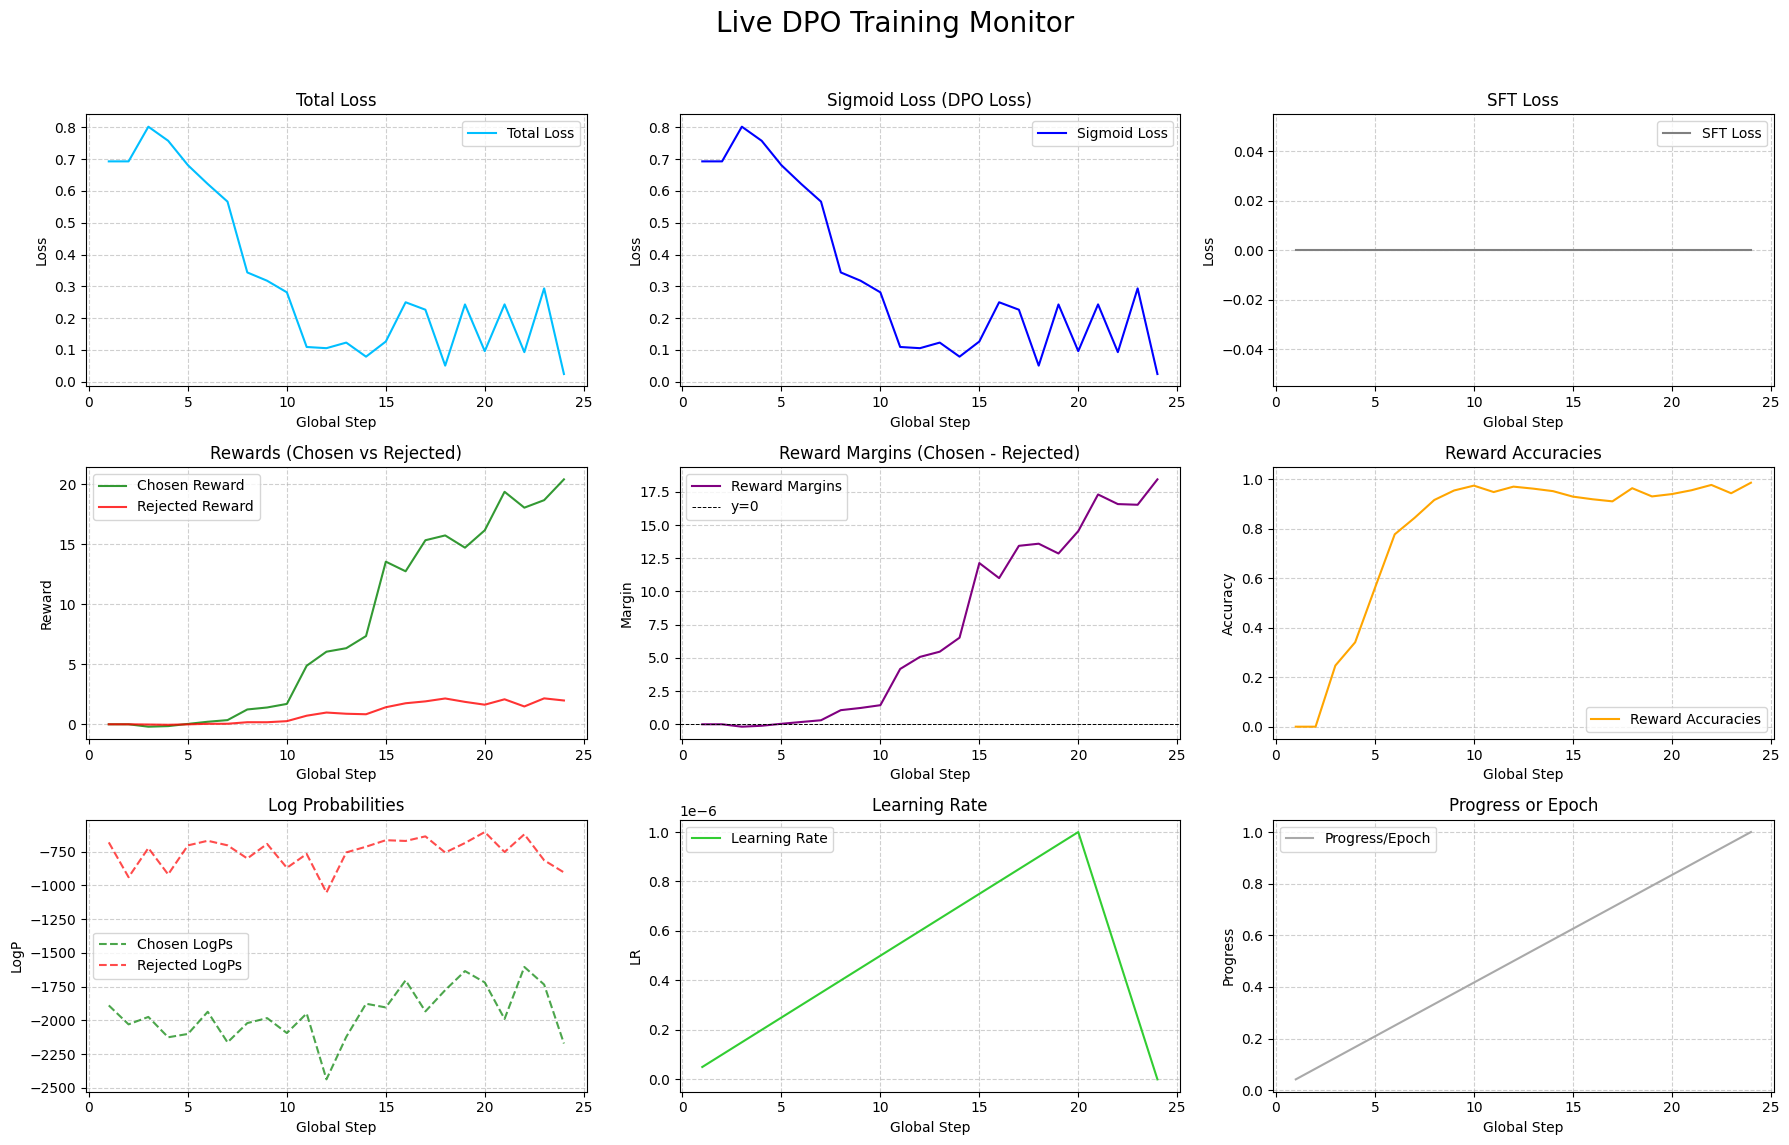

监控结束。


In [1]:
# DPO:

# 魔法命令，让 Matplotlib 的图表直接在 Notebook 的输出区域显示
%matplotlib inline

import re
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output # 导入关键的 clear_output 函数
from datetime import datetime

# ===============================================================
# 1. 配置你的日志文件路径和刷新间隔
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV
log_file_path = 'results/dpo/full_tp_pp.log' # <--- 修改这里！
update_interval_seconds = 5     # 图表每 5 秒刷新一次
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# ===============================================================


KEY_MAP = {
    'loss': 'loss',
    'learning_rate': 'lr',
    'global_step': 'step',
    'rewards/chosen': 'rewards_chosen',
    'rewards/rejected': 'rewards_rejected',
    'rewards/accuracies': 'rewards_accuracies',
    'rewards/margins': 'rewards_margins',
    'logps/rejected': 'logps_rejected',
    'logps/chosen': 'logps_chosen',
    'sigmoid_loss': 'sigmoid_loss',
    'sft_loss': 'sft_loss',
    'progress_or_epoch': 'progress'
}

# (新) 编译一个灵活的 regex，用于查找所有 "key: value" 对
# 键: 允许单词、数字、下划线和斜杠 (e.g., "rewards/chosen")
# 值: 允许数字、点、e 和负号 (e.g., "5e-07" 或 "-621.8")
FLEXIBLE_PATTERN = re.compile(r"([\w/]+):\s+([\d.e-]+)")

def parse_log_line(line):
    """
    (新) 使用更灵活的 findall 方法解析单行 DPO 训练日志。
    只提取 KEY_MAP 中定义的字段，忽略顺序和其他字段。
    """
    
    # 1. 快速跳过无效行
    if "sync gradients" in line or not line.strip():
        return None
        
    # 2. 查找所有匹配的 key-value 对
    #    findall 会返回一个元组列表, e.g., [('loss', '0.09'), ('learning_rate', '5e-07'), ...]
    matches = FLEXIBLE_PATTERN.findall(line)
    
    if not matches:
        return None # 这行有内容，但没匹配到任何 "key: value"

    # 3. 将所有找到的数据存入一个临时字典，方便查找
    found_data = dict(matches)
    
    # 4. 构建我们最终需要的 parsed_data 字典
    parsed_data = {}
    
    # 检查所有我们 *要求* 的字段是否存在
    for log_key, dict_key in KEY_MAP.items():
        if log_key not in found_data:
            # 只要我们关心的 *任何一个* 字段缺失，就判定此行为无效数据
            # (这符合你原始 regex "all-or-nothing" 的逻辑)
            # print(f"[Debug] 忽略一行, 缺少关键字段: {log_key}") # <--- 需要时取消注释
            return None
        
        # 字段存在，进行转换
        value_str = found_data[log_key]
        try:
            if dict_key == 'step':
                parsed_data[dict_key] = int(value_str)
            else:
                parsed_data[dict_key] = float(value_str)
        except ValueError:
            print(f"[Debug] 无法解析值: {log_key}={value_str}")
            return None # 值格式错误，也跳过

    # 5. 所有关心的字段都找到了，返回数据
    return parsed_data

def plot_metrics(data):
    """根据解析的 DPO 数据进行绘图。"""
    if not data or not data['step']:
        print("텅텅 未从日志中解析出任何有效数据，等待日志更新...")
        return
    
    # 使用 data['step'] 作为所有图表的 x 轴
    steps = data['step']
    
    # 创建 3x3 的子图布局
    fig, axes = plt.subplots(3, 3, figsize=(18, 12)) 
    fig.suptitle('Live DPO Training Monitor', fontsize=20)

    # 1. 总 Loss
    ax = axes[0, 0]
    ax.plot(steps, data['loss'], label='Total Loss', color='deepskyblue')
    ax.set_title('Total Loss'); ax.set_xlabel('Global Step'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 2. Sigmoid Loss
    ax = axes[0, 1]
    ax.plot(steps, data['sigmoid_loss'], label='Sigmoid Loss', color='blue')
    ax.set_title('Sigmoid Loss (DPO Loss)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
    
    # 3. SFT Loss
    ax = axes[0, 2]
    ax.plot(steps, data['sft_loss'], label='SFT Loss', color='gray')
    ax.set_title('SFT Loss'); ax.set_xlabel('Global Step'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
    
    # 4. Rewards (Chosen vs Rejected)
    ax = axes[1, 0]
    ax.plot(steps, data['rewards_chosen'], label='Chosen Reward', color='green', alpha=0.8)
    ax.plot(steps, data['rewards_rejected'], label='Rejected Reward', color='red', alpha=0.8)
    ax.set_title('Rewards (Chosen vs Rejected)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Reward')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 5. Reward Margins
    ax = axes[1, 1]
    ax.plot(steps, data['rewards_margins'], label='Reward Margins', color='purple')
    # 添加 y=0 的参考线
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, label='y=0')
    ax.set_title('Reward Margins (Chosen - Rejected)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Margin')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 6. Reward Accuracies
    ax = axes[1, 2]
    ax.plot(steps, data['rewards_accuracies'], label='Reward Accuracies', color='orange')
    ax.set_ylim(-0.05, 1.05) # 准确率在 0-1 之间
    ax.set_title('Reward Accuracies'); ax.set_xlabel('Global Step'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 7. LogPs (Chosen vs Rejected)
    ax = axes[2, 0]
    ax.plot(steps, data['logps_chosen'], label='Chosen LogPs', color='green', alpha=0.7, linestyle='--')
    ax.plot(steps, data['logps_rejected'], label='Rejected LogPs', color='red', alpha=0.7, linestyle='--')
    ax.set_title('Log Probabilities'); ax.set_xlabel('Global Step'); ax.set_ylabel('LogP')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 8. Learning Rate
    ax = axes[2, 1]
    ax.plot(steps, data['lr'], label='Learning Rate', color='limegreen')
    ax.set_title('Learning Rate'); ax.set_xlabel('Global Step'); ax.set_ylabel('LR')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 9. Progress or Epoch
    ax = axes[2, 2]
    ax.plot(steps, data['progress'], label='Progress/Epoch', color='darkgray')
    ax.set_title('Progress or Epoch'); ax.set_xlabel('Global Step'); ax.set_ylabel('Progress')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # 调整布局为 suptitle 留出空间
    plt.show()

# --- 主循环：实时监控 (全量更新版) ---

# 1. 在 try 循环外部声明 data，以便在 KeyboardInterrupt (手动停止) 时可以访问到最后的数据
data = defaultdict(list) 

try:
    print("🚀 开始实时监控日志文件... (点击 Notebook 的停止按钮来中断)")
    
    while True:
        # 2. 每次循环都创建新的临时数据字典 (实现全量更新)
        current_data = defaultdict(list) 
        has_valid_data = False # 标志位：是否解析到了有效数据
        file_found = True      # 标志位：文件是否存在
        file_empty = True      # 标志位：文件是否为空

        try:
            # 3. 每次循环都重新打开并读取整个文件
            # 使用 'with' 语句确保文件总能正确关闭
            with open(log_file_path, 'r', encoding='utf-8') as f:
                all_lines = f.readlines()
            
            if all_lines:
                file_empty = False
                # 4. 解析所有行
                for line in all_lines:
                    parsed_data = parse_log_line(line)
                    if parsed_data:
                        has_valid_data = True
                        for key, value in parsed_data.items():
                            current_data[key].append(value)
            
        except FileNotFoundError:
            file_found = False
        
        # 5. 清空 Notebook 输出区域，准备重绘
        clear_output(wait=True)
        
        # 打印当前时间和状态
        print(f"✅ 最后更新于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        if not file_found:
            print(f"❌ 错误: 找不到日志文件 {log_file_path}，正在等待文件创建...")
        elif file_empty:
             print("日志文件为空，等待数据写入...")
        elif not has_valid_data:
            print("日志已读取，但未解析到有效 DPO 数据行...")

        # 6. 绘制图表 (plot_metrics 内部会处理 current_data 为空的情况)
        plot_metrics(current_data)
        
        # 7. 将当前数据保存到外部 data 变量中，以便中断时使用
        #    (只有在成功解析后才更新，防止文件突然丢失导致 data 被清空)
        if file_found and has_valid_data:
             data = current_data
        elif not file_found or file_empty:
             # 如果文件找不到或为空，也清空 data，以便中断时显示空图
             data = defaultdict(list) 

        # 8. 等待指定的间隔时间
        time.sleep(update_interval_seconds)

except KeyboardInterrupt:
    print("\n🛑 监控已由用户手动停止。")
    print("正在生成最终图表...")
    clear_output(wait=True)
    print(f"✅ 最终图表生成于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    # 绘制最后一次成功解析的数据
    plot_metrics(data) 

except Exception as e:
    # 捕获其他潜在异常
    print(f"\n❌ 发生意外错误: {e}")

finally:
    # 在全量更新模式下，文件句柄是自动管理的 (with open)，
    # 所以不需要在这里显式关闭。
    print("监控结束。")

✅ 最终图表生成于: 2025-10-24 09:38:28


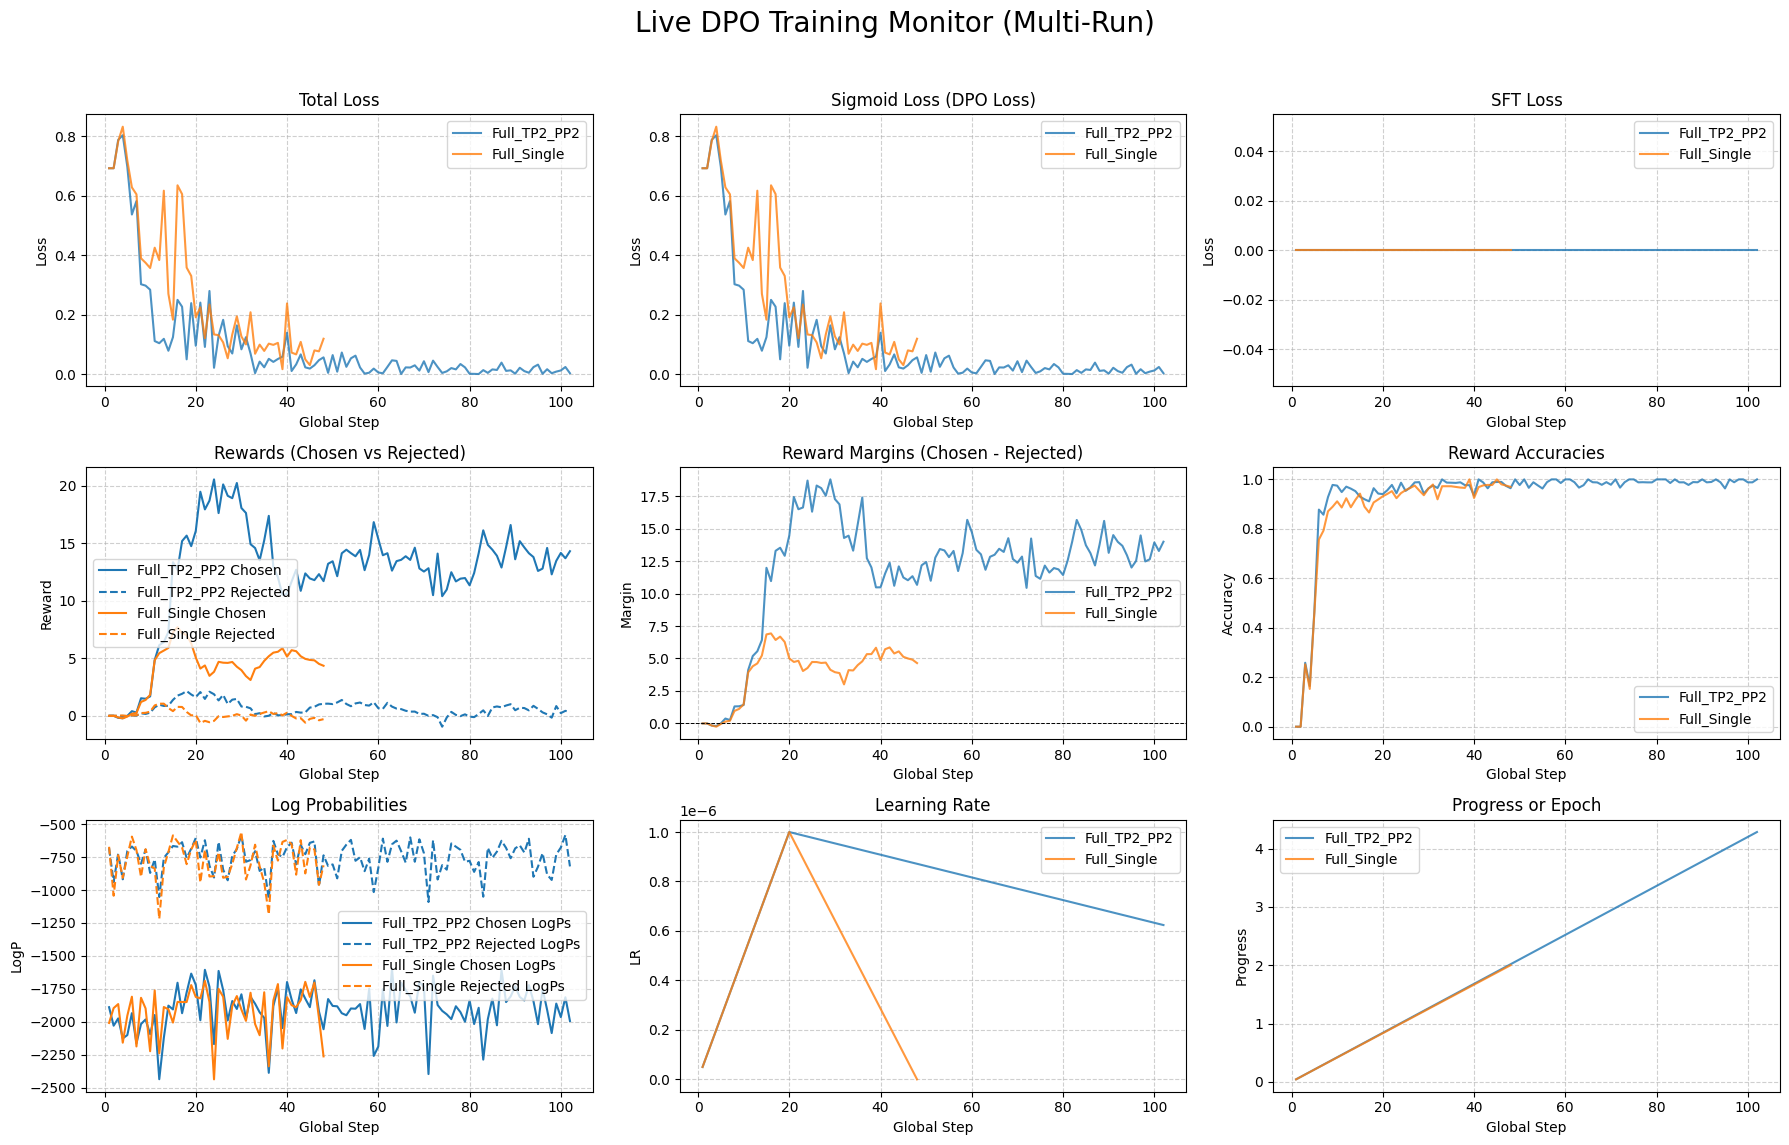

监控结束。


In [3]:
# DPO - (多文件监控版)

# 魔法命令，让 Matplotlib 的图表直接在 Notebook 的输出区域显示
%matplotlib inline

import re
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output # 导入关键的 clear_output 函数
from datetime import datetime

# ===============================================================
# 1. 配置你的日志文件路径和刷新间隔
# VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

# (新) 使用字典配置多个日志文件
# 格式: { "你为这个日志取的名字": "日志文件路径" }
log_file_map = {
    'Full_TP2_PP2': 'results/dpo/full_tp_pp.log',
    'Full_Single': 'results/dpo/full.log'
}
update_interval_seconds = 5     # 图表每 5 秒刷新一次

# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# ===============================================================


# ===============================================================
# 2. (新) 更健壮的日志解析逻辑 (来自你之前的请求)
# ===============================================================

# (新) 定义我们关心的日志键 -> 绘图时使用的字典键
KEY_MAP = {
    'loss': 'loss',
    'learning_rate': 'lr',
    'global_step': 'step',
    'rewards/chosen': 'rewards_chosen',
    'rewards/rejected': 'rewards_rejected',
    'rewards/accuracies': 'rewards_accuracies',
    'rewards/margins': 'rewards_margins',
    'logps/rejected': 'logps_rejected',
    'logps/chosen': 'logps_chosen',
    'sigmoid_loss': 'sigmoid_loss',
    'sft_loss': 'sft_loss',
    'progress_or_epoch': 'progress'
}

# (新) 编译一个灵活的 regex，用于查找所有 "key: value" 对
FLEXIBLE_PATTERN = re.compile(r"([\w/]+):\s+([\d.e-]+)")

def parse_log_line(line):
    """
    (新) 使用更灵活的 findall 方法解析单行 DPO 训练日志。
    只提取 KEY_MAP 中定义的字段，忽略顺序和其他字段。
    """
    
    # 1. 快速跳过无效行
    if "sync gradients" in line or not line.strip():
        return None
        
    # 2. 查找所有匹配的 key-value 对
    matches = FLEXIBLE_PATTERN.findall(line)
    
    if not matches:
        return None # 这行有内容，但没匹配到任何 "key: value"

    # 3. 将所有找到的数据存入一个临时字典，方便查找
    found_data = dict(matches)
    
    # 4. 构建我们最终需要的 parsed_data 字典
    parsed_data = {}
    
    # 检查所有我们 *要求* 的字段是否存在
    for log_key, dict_key in KEY_MAP.items():
        if log_key not in found_data:
            # 只要我们关心的 *任何一个* 字段缺失，就判定此行为无效数据
            # print(f"[Debug] 忽略一行, 缺少关键字段: {log_key}") 
            return None
        
        # 字段存在，进行转换
        value_str = found_data[log_key]
        try:
            if dict_key == 'step':
                parsed_data[dict_key] = int(value_str)
            else:
                parsed_data[dict_key] = float(value_str)
        except ValueError:
            # print(f"[Debug] 无法解析值: {log_key}={value_str}")
            return None # 值格式错误，也跳过

    # 5. 所有关心的字段都找到了，返回数据
    return parsed_data

# ===============================================================
# 3. (新) 重构后的多文件绘图函数
# ===============================================================

def plot_metrics_multi(all_data):
    """
    (新) 根据解析的 *多个模型* 的 DPO 数据进行绘图。
    all_data 结构: { "model_name": data_dict }
    """
    
    # 检查是否有任何数据
    has_any_data = any(data.get('step') for data in all_data.values())
    
    if not has_any_data:
        print("텅텅 未从任何日志中解析出有效数据，等待日志更新...")
        return
    
    # 为不同的日志文件生成不同的颜色
    colors = plt.cm.tab10(range(len(all_data)))
    
    # 创建 3x3 的子图布局
    fig, axes = plt.subplots(3, 3, figsize=(18, 12)) 
    fig.suptitle('Live DPO Training Monitor (Multi-Run)', fontsize=20)
    
    # --- 循环绘制所有子图 ---
    
    def plot_simple(ax, metric_key, title, ylabel):
        """辅助函数，用于绘制单指标图表"""
        ax.set_title(title); ax.set_xlabel('Global Step'); ax.set_ylabel(ylabel)
        for i, (name, data) in enumerate(all_data.items()):
            if data.get('step'): # 确保该模型有数据
                ax.plot(data['step'], data[metric_key], label=f'{name}', color=colors[i], alpha=0.8)
        ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 1. 总 Loss
    plot_simple(axes[0, 0], 'loss', 'Total Loss', 'Loss')

    # 2. Sigmoid Loss
    plot_simple(axes[0, 1], 'sigmoid_loss', 'Sigmoid Loss (DPO Loss)', 'Loss')
    
    # 3. SFT Loss
    plot_simple(axes[0, 2], 'sft_loss', 'SFT Loss', 'Loss')
    
    # 4. Rewards (Chosen vs Rejected) - 特殊处理
    ax = axes[1, 0]
    ax.set_title('Rewards (Chosen vs Rejected)'); ax.set_xlabel('Global Step'); ax.set_ylabel('Reward')
    for i, (name, data) in enumerate(all_data.items()):
        if data.get('step'):
            # 用同色、不同线型来区分 Chosen 和 Rejected
            ax.plot(data['step'], data['rewards_chosen'], label=f'{name} Chosen', color=colors[i], linestyle='-')
            ax.plot(data['step'], data['rewards_rejected'], label=f'{name} Rejected', color=colors[i], linestyle='--')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 5. Reward Margins
    plot_simple(axes[1, 1], 'rewards_margins', 'Reward Margins (Chosen - Rejected)', 'Margin')
    axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.7) # 添加 y=0 参考线

    # 6. Reward Accuracies
    plot_simple(axes[1, 2], 'rewards_accuracies', 'Reward Accuracies', 'Accuracy')
    axes[1, 2].set_ylim(-0.05, 1.05) # 准确率在 0-1 之间

    # 7. LogPs (Chosen vs Rejected) - 特殊处理
    ax = axes[2, 0]
    ax.set_title('Log Probabilities'); ax.set_xlabel('Global Step'); ax.set_ylabel('LogP')
    for i, (name, data) in enumerate(all_data.items()):
        if data.get('step'):
            ax.plot(data['step'], data['logps_chosen'], label=f'{name} Chosen LogPs', color=colors[i], linestyle='-')
            ax.plot(data['step'], data['logps_rejected'], label=f'{name} Rejected LogPs', color=colors[i], linestyle='--')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

    # 8. Learning Rate
    plot_simple(axes[2, 1], 'lr', 'Learning Rate', 'LR')

    # 9. Progress or Epoch
    plot_simple(axes[2, 2], 'progress', 'Progress or Epoch', 'Progress')


    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # 调整布局为 suptitle 留出空间
    plt.show()

# ===============================================================
# 4. (新) 主循环：实时监控 (全量更新版 + 多文件版)
# ===============================================================

# 1. 在 try 循环外部声明 all_data_final，以便在 KeyboardInterrupt (手动停止) 时可以访问到最后的数据
#    (新) 根据 log_file_map 初始化这个嵌套字典
all_data_final = {name: defaultdict(list) for name in log_file_map} 

try:
    print("🚀 开始实时监控多个日志文件... (点击 Notebook 的停止按钮来中断)")
    
    while True:
        # 2. 每次循环都创建新的临时数据字典 (实现全量更新)
        current_all_data = {name: defaultdict(list) for name in log_file_map} 
        
        status_messages = []     # (新) 存储每个文件的状态
        has_any_valid_data = False # (新) 标志位：是否有任何文件解析到了数据

        # 3. (新) 循环遍历所有在 log_file_map 中定义的日志文件
        for name, path in log_file_map.items():
            try:
                # 3a. 每次循环都重新打开并读取整个文件
                with open(path, 'r', encoding='utf-8') as f:
                    all_lines = f.readlines()
                
                if not all_lines:
                    status_messages.append(f"🟡 {name} ({path}): 日志文件为空。")
                    continue # 继续检查下一个文件

                file_has_data = False # 标志位：当前文件是否有数据
                
                # 3b. 解析所有行
                for line in all_lines:
                    parsed_data = parse_log_line(line)
                    if parsed_data:
                        file_has_data = True
                        has_any_valid_data = True # 设置全局标志
                        # (新) 将数据存入对应模型的字典中
                        for key, value in parsed_data.items():
                            current_all_data[name][key].append(value)
                
                if file_has_data:
                    step_count = len(current_all_data[name].get('step', []))
                    status_messages.append(f"✅ {name} ({path}): OK ({step_count} steps)")
                else:
                    status_messages.append(f"🟡 {name} ({path}): 日志已读取，但未解析到有效 DPO 数据行。")

            except FileNotFoundError:
                status_messages.append(f"❌ {name} ({path}): 找不到日志文件。")
            except Exception as e:
                status_messages.append(f"🔥 {name} ({path}): 读取时发生错误 - {e}")
        
        # 4. 清空 Notebook 输出区域，准备重绘
        clear_output(wait=True)
        
        # 5. 打印当前时间和所有文件的状态
        print(f"✅ 最后更新于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("--- 日志文件状态 ---")
        for msg in status_messages:
            print(msg)
        print("----------------------\n")
        
        # 6. (新) 调用多文件绘图函数
        plot_metrics_multi(current_all_data)
        
        # 7. 将当前数据保存到外部 data 变量中，以便中断时使用
        all_data_final = current_all_data

        # 8. 等待指定的间隔时间
        time.sleep(update_interval_seconds)

except KeyboardInterrupt:
    print("\n🛑 监控已由用户手动停止。")
    print("正在生成最终图表...")
    clear_output(wait=True)
    print(f"✅ 最终图表生成于: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    # (新) 绘制最后一次成功解析的多模型数据
    plot_metrics_multi(all_data_final) 

except Exception as e:
    # 捕获其他潜在异常
    print(f"\n❌ 发生意外错误: {e}")

finally:
    # 在全量更新模式下，文件句柄是自动管理的 (with open)，
    # 所以不需要在这里显式关闭。
    print("监控结束。")